In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.decomposition import PCA

In [5]:
PROCESSED = '/content/drive/MyDrive/Yelp JSON/yelp_dataset/data/processed/'

In [ ]:
# W5 — CITY-LEVEL FEATURE MATRIX
#  One row per city

business   = pd.read_parquet(PROCESSED + 'business_clean.parquet')
bridge     = pd.read_parquet(PROCESSED + 'business_categories.parquet')
checkin    = pd.read_parquet(PROCESSED + 'checkin_clean.parquet')
interact   = pd.read_parquet(PROCESSED + 'review_interactions.parquet')

print(f'Unique cities on dataset: {business["city"].nunique():,}')

Unique cities on dataset: 1,416


In [ ]:
business.describe()

,latitude,longitude,stars,review_count,is_open,n_categories,hours__open_days,hours__has_weekend,hours__open_monday,hours__open_tuesday,hours__open_wednesday,hours__open_thursday,hours__open_friday,hours__open_saturday,hours__open_sunday
count,150346.000000,150346.000000,150346.000000,150346.000000,150346.00000,150346.000000,150346.000000,150346.000000,150346.000000,150346.000000,150346.000000,150346.000000,150346.000000,150346.000000,150346.000000
mean,36.671150,-89.357339,3.596724,44.866561,0.79615,4.447022,5.327811,0.740938,0.761404,0.802356,0.823241,0.832732,0.831409,0.736767,0.539901
std,5.872759,14.918502,0.974421,121.120136,0.40286,2.233734,2.445235,0.438121,0.426227,0.398224,0.381466,0.373216,0.374392,0.440389,0.498407
min,27.555127,-120.095137,1.000000,5.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.187293,-90.357810,3.000000,8.000000,1.00000,3.000000,5.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
50%,38.777413,-86.121179,3.500000,15.000000,1.00000,4.000000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,39.954036,-75.421542,4.500000,37.000000,1.00000,6.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,53.679197,-73.200457,5.000000,7568.000000,1.00000,36.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
business.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150346 entries, 0 to 150345
Data columns (total 58 columns):
 #   Column                            Non-Null Count   Dtype   
---  ------                            --------------   -----   
 0   business_id                       150346 non-null  object  
 1   name                              150346 non-null  object  
 2   city                              150346 non-null  object  
 3   state                             150346 non-null  object  
 4   latitude                          150346 non-null  float64 
 5   longitude                         150346 non-null  float64 
 6   stars                             150346 non-null  float64 
 7   review_count                      150346 non-null  int64   
 8   is_open                           150346 non-null  int64   
 9   categories_list                   150346 non-null  object  
 10  primary_category                  150243 non-null  object  
 11  n_categories                      15034

In [ ]:
# basic metrics of businesses per city
# it captures a city's general profile on quality(stars) and activity(reviews)

bus_per_city = business.groupby('city').agg(
    n_businesses      = ('business_id', 'count'),        # size of city
    avg_stars         = ('stars', 'mean'),               # average stars
    median_stars      = ('stars', 'median'),             # median stars
    std_stars         = ('stars', 'std'),                # quantifies the amount of variation of stars around their mean
    total_reviews     = ('review_count', 'sum'),         # total reviews (activity)
    avg_reviews_per_biz = ('review_count', 'mean'),      # avg of total reviews
    pct_open          = ('is_open', 'mean'),             # % of open businesses
    avg_n_categories  = ('n_categories', 'mean'),        # avg categories of businesses
).reset_index()

print(f'Businesses per city info shape: {bus_per_city.shape}')
print(bus_per_city.head(3))

Businesses per city info shape: (1416, 9)
          city  n_businesses  avg_stars  median_stars  std_stars  \
0  AB Edmonton             1        4.5           4.5        NaN   
1       AMBLER             1        3.0           3.0        NaN   
2      ARDMORE             1        3.0           3.0        NaN   

   total_reviews  avg_reviews_per_biz  pct_open  avg_n_categories  
0              6                  6.0       1.0               2.0  
1              9                  9.0       1.0               4.0  
2              8                  8.0       1.0               4.0  


## attributes per city
business_clean (columns attr__ boolean)

it captures the city "type" ( turism, family, nightlife, etc.)
from attributes of the businesses

In [ ]:
attr_city = [c for c in business.columns if c.startswith('attr__')
             and business[c].dtype == 'boolean']

# Converts boolean to int to do means and completes null values with false(0)
biz_attrs = business[['city'] + attr_city].copy()
for c in attr_city:
    biz_attrs[c] = biz_attrs[c].astype('object').map(
        {True: 1, False: 0, 'True': 1, 'False': 0}
    ).fillna(0).astype(float)

In [ ]:
biz_attrs.head()

,city,attr__ByAppointmentOnly,attr__BusinessAcceptsCreditCards,attr__BikeParking,attr__RestaurantsTakeOut,attr__RestaurantsDelivery,attr__Caters,attr__BusinessParking__garage,attr__BusinessParking__street,attr__BusinessParking__validated,...,attr__Ambience__classy,attr__Ambience__trendy,attr__Ambience__upscale,attr__Ambience__casual,attr__GoodForMeal__dessert,attr__GoodForMeal__latenight,attr__GoodForMeal__lunch,attr__GoodForMeal__dinner,attr__GoodForMeal__brunch,attr__GoodForMeal__breakfast
0,Santa Barbara,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Affton,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Tucson,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Philadelphia,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Green Lane,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# we verify there's not a null value
biz_attrs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150346 entries, 0 to 150345
Data columns (total 33 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   city                              150346 non-null  object 
 1   attr__ByAppointmentOnly           150346 non-null  float64
 2   attr__BusinessAcceptsCreditCards  150346 non-null  float64
 3   attr__BikeParking                 150346 non-null  float64
 4   attr__RestaurantsTakeOut          150346 non-null  float64
 5   attr__RestaurantsDelivery         150346 non-null  float64
 6   attr__Caters                      150346 non-null  float64
 7   attr__BusinessParking__garage     150346 non-null  float64
 8   attr__BusinessParking__street     150346 non-null  float64
 9   attr__BusinessParking__validated  150346 non-null  float64
 10  attr__BusinessParking__lot        150346 non-null  float64
 11  attr__BusinessParking__valet      150346 non-null  f

In [ ]:
# mean per city: ex."40% of businesses on this city have a romantic ambience"
at_per_city = biz_attrs.groupby('city')[attr_city].mean().reset_index()

# rename for clarity
at_per_city.columns = ['city'] + ['city_pct_' + c.replace('attr__', '')
                               for c in attr_city]

print(f'Attributes per city shape: {at_per_city.shape}')

Attributes per city shape: (1416, 33)


In [ ]:
# we add categoricals now
# PriceRange (ordinal)
price_map = {'1': 1, '2': 2, '3': 3, '4': 4}
business['price_num'] = business['attr__RestaurantsPriceRange2'].astype(str).map(price_map)

# NoiseLevel (ordinal)
noise_map = {'quiet': 1, 'average': 2, 'loud': 3, 'very_loud': 4}
business['noise_num'] = business['attr__NoiseLevel'].astype(str).map(noise_map)

# fill nans
business['price_num'] = business['price_num'].fillna(business['price_num'].median())
business['noise_num'] = business['noise_num'].fillna(business['noise_num'].median())

# WiFi, Alcohol, Attire → % of every business per city
wifi_dummies    = pd.get_dummies(business['attr__WiFi'],             prefix='wifi')
alcohol_dummies = pd.get_dummies(business['attr__Alcohol'],          prefix='alcohol')
attire_dummies  = pd.get_dummies(business['attr__RestaurantsAttire'], prefix='attire')

In [ ]:
wifi_dummies.shape

(150346, 3)

In [ ]:
biz_extra = pd.concat([
    business[['city', 'price_num', 'noise_num']],
    wifi_dummies,
    alcohol_dummies,
    attire_dummies
], axis=1)

# aggregates per city
at_per_city_extra = biz_extra.groupby('city').mean().reset_index()
# mean() on dummies gives % of businesses with that attribute
# mean() on price_num, noise_num gives ordinal mean

print(f'Attributes per city shape: {at_per_city_extra.shape}')

Attributes per city shape: (1416, 12)


In [ ]:
# combine at_per_city with at_per_city_extra
at_per_city = at_per_city.merge(at_per_city_extra, on='city', how='left')

In [ ]:
at_per_city.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 44 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   city                                 1416 non-null   object 
 1   city_pct_ByAppointmentOnly           1416 non-null   float64
 2   city_pct_BusinessAcceptsCreditCards  1416 non-null   float64
 3   city_pct_BikeParking                 1416 non-null   float64
 4   city_pct_RestaurantsTakeOut          1416 non-null   float64
 5   city_pct_RestaurantsDelivery         1416 non-null   float64
 6   city_pct_Caters                      1416 non-null   float64
 7   city_pct_BusinessParking__garage     1416 non-null   float64
 8   city_pct_BusinessParking__street     1416 non-null   float64
 9   city_pct_BusinessParking__validated  1416 non-null   float64
 10  city_pct_BusinessParking__lot        1416 non-null   float64
 11  city_pct_BusinessParking__vale

In [ ]:
new_column_names = {}
for col in at_per_city.columns:
    if col not in ['city'] and not col.startswith('city_pct_') and col not in['price_num'] and col not in ['noise_num']:
        new_column_names[col] = 'city_pct_' + col

at_per_city = at_per_city.rename(columns=new_column_names)

print(f'Attributes per city shape after renaming: {at_per_city.shape}')

Attributes per city shape after renaming: (1416, 44)


In [ ]:
at_per_city.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 44 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   city                                 1416 non-null   object 
 1   city_pct_ByAppointmentOnly           1416 non-null   float64
 2   city_pct_BusinessAcceptsCreditCards  1416 non-null   float64
 3   city_pct_BikeParking                 1416 non-null   float64
 4   city_pct_RestaurantsTakeOut          1416 non-null   float64
 5   city_pct_RestaurantsDelivery         1416 non-null   float64
 6   city_pct_Caters                      1416 non-null   float64
 7   city_pct_BusinessParking__garage     1416 non-null   float64
 8   city_pct_BusinessParking__street     1416 non-null   float64
 9   city_pct_BusinessParking__validated  1416 non-null   float64
 10  city_pct_BusinessParking__lot        1416 non-null   float64
 11  city_pct_BusinessParking__vale

we verify its well constructed by showing an ex. with Philadelphia city

In [ ]:
biz_attrs['city'].value_counts()

,count
city,
Philadelphia,14569
Tucson,9250
Tampa,9050
Indianapolis,7540
Nashville,6971
...,...
Wesley Chapel FL,1
Monchanin,1
Lower Southampton,1


In [ ]:
Phil_city = at_per_city[at_per_city['city']=='Philadelphia']

Philadelphia is more of a family centered(good for kids) city rather than a romantic one

In [ ]:
Phil_city['city_pct_Ambience__romantic']

,city_pct_Ambience__romantic
866,0.007825


In [ ]:
Phil_city['city_pct_GoodForKids']

,city_pct_GoodForKids
866,0.288695


/tmp/ipykernel_10903/2298015878.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Average Percentage', y='Attribute', data=plot_data, palette='viridis')


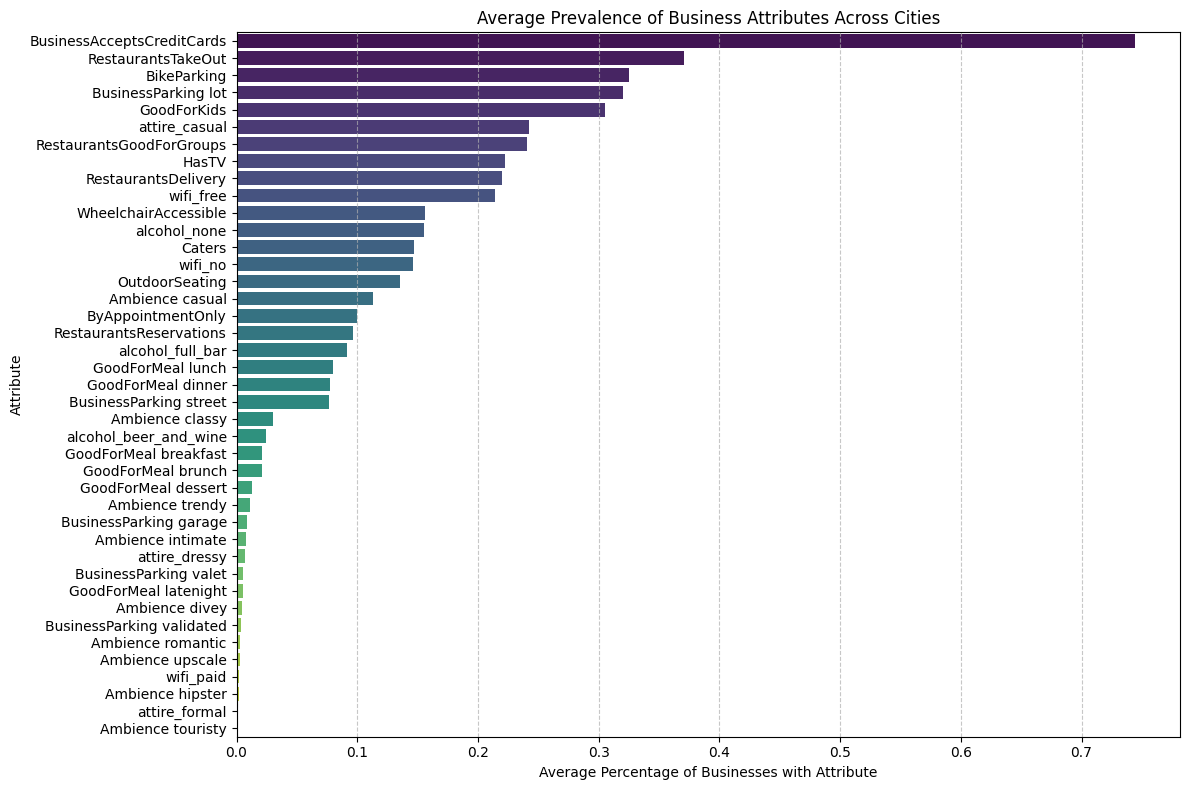

In [ ]:
# attribute columns (excluding 'city')
attribute_cols = [col for col in at_per_city.columns if col.startswith('city_pct_')]

# Calculate mean of each attribute across all cities
mean_attributes = at_per_city[attribute_cols].mean().sort_values(ascending=False)

plot_data = pd.DataFrame({
    'Attribute': mean_attributes.index.str.replace('city_pct_', '').str.replace('__', ' ', regex=False),
    'Average Percentage': mean_attributes.values
})

plt.figure(figsize=(12, 8))
sns.barplot(x='Average Percentage', y='Attribute', data=plot_data, palette='viridis')
plt.title('Average Prevalence of Business Attributes Across Cities')
plt.xlabel('Average Percentage of Businesses with Attribute')
plt.ylabel('Attribute')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

With the graph we can conclude that most businesses accept credit cards (aprx 75%)

In [ ]:
credit_card_acceptance = at_per_city.sort_values(by='city_pct_BusinessAcceptsCreditCards', ascending=False).head(590)
credit_card_acceptance.tail(35)

,city,city_pct_ByAppointmentOnly,city_pct_BusinessAcceptsCreditCards,city_pct_BikeParking,city_pct_RestaurantsTakeOut,city_pct_RestaurantsDelivery,city_pct_Caters,city_pct_BusinessParking__garage,city_pct_BusinessParking__street,city_pct_BusinessParking__validated,...,noise_num,city_pct_wifi_free,city_pct_wifi_no,city_pct_wifi_paid,city_pct_alcohol_beer_and_wine,city_pct_alcohol_full_bar,city_pct_alcohol_none,city_pct_attire_casual,city_pct_attire_dressy,city_pct_attire_formal
1387,lutz,0.666667,1.000000,0.666667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
327,Elmwood,0.222222,0.944444,0.222222,0.222222,0.166667,0.055556,0.000000,0.055556,0.000000,...,2.000000,0.333333,0.055556,0.000000,0.055556,0.055556,0.000000,0.000000,0.000000,0.0
1037,Shrewsbury,0.058824,0.941176,0.294118,0.235294,0.294118,0.058824,0.000000,0.000000,0.000000,...,2.058824,0.058824,0.058824,0.058824,0.000000,0.058824,0.117647,0.176471,0.000000,0.0
141,Cahokia,0.000000,0.941176,0.352941,0.823529,0.705882,0.294118,0.000000,0.000000,0.000000,...,2.000000,0.235294,0.235294,0.000000,0.058824,0.117647,0.411765,0.588235,0.000000,0.0
1314,Westmont,0.000000,0.935484,0.677419,0.580645,0.290323,0.225806,0.000000,0.387097,0.000000,...,2.032258,0.258065,0.290323,0.000000,0.000000,0.129032,0.322581,0.387097,0.000000,0.0
949,Rosemont,0.200000,0.933333,0.466667,0.400000,0.333333,0.200000,0.066667,0.066667,0.000000,...,1.866667,0.200000,0.200000,0.000000,0.000000,0.133333,0.333333,0.400000,0.000000,0.0
21,Arabi,0.000000,0.923077,0.576923,0.615385,0.423077,0.192308,0.000000,0.192308,0.000000,...,1.884615,0.307692,0.153846,0.038462,0.153846,0.115385,0.115385,0.461538,0.000000,0.0
1200,Treasure Is,0.076923,0.923077,0.076923,0.000000,0.000000,0.000000,0.000000,0.076923,0.000000,...,2.000000,0.846154,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
759,New Palestine,0.076923,0.923077,0.461538,0.769231,0.384615,0.000000,0.000000,0.000000,0.000000,...,1.923077,0.230769,0.384615,0.000000,0.000000,0.230769,0.230769,0.538462,0.000000,0.0
1207,Trooper,0.076923,0.923077,0.307692,0.615385,0.461538,0.384615,0.000000,0.000000,0.000000,...,1.923077,0.076923,0.307692,0.000000,0.000000,0.000000,0.384615,0.538462,0.000000,0.0


In [ ]:
# Sort DataFrame by 'city_pct_BusinessAcceptsCreditCards' in descending order
credit_card_acceptance = at_per_city.sort_values(by='city_pct_BusinessAcceptsCreditCards', ascending=False).head(590)
credit_card_acceptance = credit_card_acceptance.tail(35)
fig = px.bar(
    credit_card_acceptance,
    x='city',
    y='city_pct_BusinessAcceptsCreditCards',
    title='Percentage of Businesses Accepting Credit Cards (555-590)',
    labels={
        'city': 'City',
        'city_pct_BusinessAcceptsCreditCards': 'Percentage of Businesses Accepting Credit Cards'
    },
    hover_data={'city': True, 'city_pct_BusinessAcceptsCreditCards': ':.2%'}, # Format hover data as percentage
    color_discrete_sequence=px.colors.qualitative.Plotly # Use a nice color sequence
)

fig.update_layout(xaxis_title='City', yaxis_title='Percentage Accepting Credit Cards')
fig.show()

##Distribution of categories per city

In [ ]:
bridgelisted = bridge['category'].value_counts()

In [ ]:
bridgelisted.shape

(1311,)

In [ ]:
# we pick 101 because it covers 70% of categories for all businesses
bl_percentage = bridgelisted.cumsum() / bridgelisted.sum()
cut_70 = np.argmax(bl_percentage >= 0.70)
print("Top 70%:", cut_70)

Top 70%: 101


Why 101 and not all 1311? Because rare categories add noise and make the matrix huge. Top 101 covers 70% of categories for all businesses

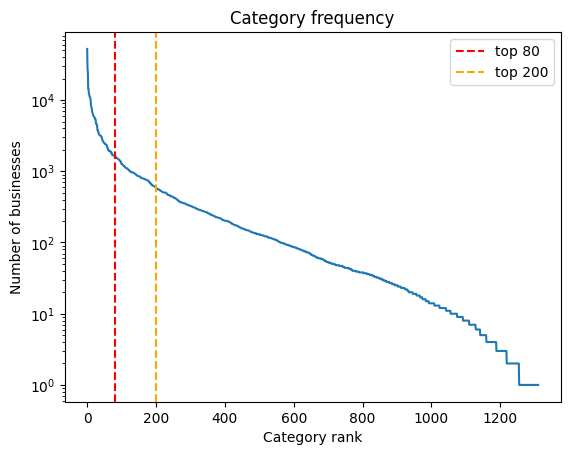

In [ ]:
# is a long-tail case
plt.plot(range(len(bridgelisted)), bridgelisted.values)
plt.axvline(80,  color='red',    linestyle='--', label='top 80')
plt.axvline(200, color='orange', linestyle='--', label='top 200')
plt.xlabel('Category rank')
plt.ylabel('Number of businesses')
plt.title('Category frequency')
plt.legend()
plt.yscale('log')
plt.show()

In [ ]:
#  business_categories bridge
#  "personality" of a city is defined by what types of businesses its got
TOP_CATS = 101  # we dont add more to prevent noise

top_cats = bridge['category'].value_counts().head(TOP_CATS).index.tolist()
bridge_top = bridge[bridge['category'].isin(top_cats)].copy()

In [ ]:
bridge_top.info()

<class 'pandas.core.frame.DataFrame'>
Index: 466798 entries, 0 to 668588
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   business_id  466798 non-null  object
 1   category     466798 non-null  object
dtypes: object(2)
memory usage: 10.7+ MB


In [ ]:
# quantity of businesses per category
bridge_city = bridge_top.merge(
    business[['business_id', 'city']], on='business_id', how='left'
)

In [ ]:
# Pivot: city × category = % of businesses belonging to a specific category within each city.
cat_counts = bridge_city.groupby(['city', 'category']).size().reset_index(name='count')
city_totals = business.groupby('city')['business_id'].count().reset_index(name='total')
cat_counts  = cat_counts.merge(city_totals, on='city')
cat_counts['pct'] = cat_counts['count'] / cat_counts['total']

city_category = cat_counts.pivot_table(
    index='city', columns='category', values='pct', fill_value=0
).reset_index()
city_category.columns.name = None
city_category.columns = ['city'] + ['cat_pct__' + c.replace(' ', '_')
                               for c in city_category.columns[1:]]

print(f'City X Category shape: {city_category.shape}')

City X Category shape: (1414, 102)


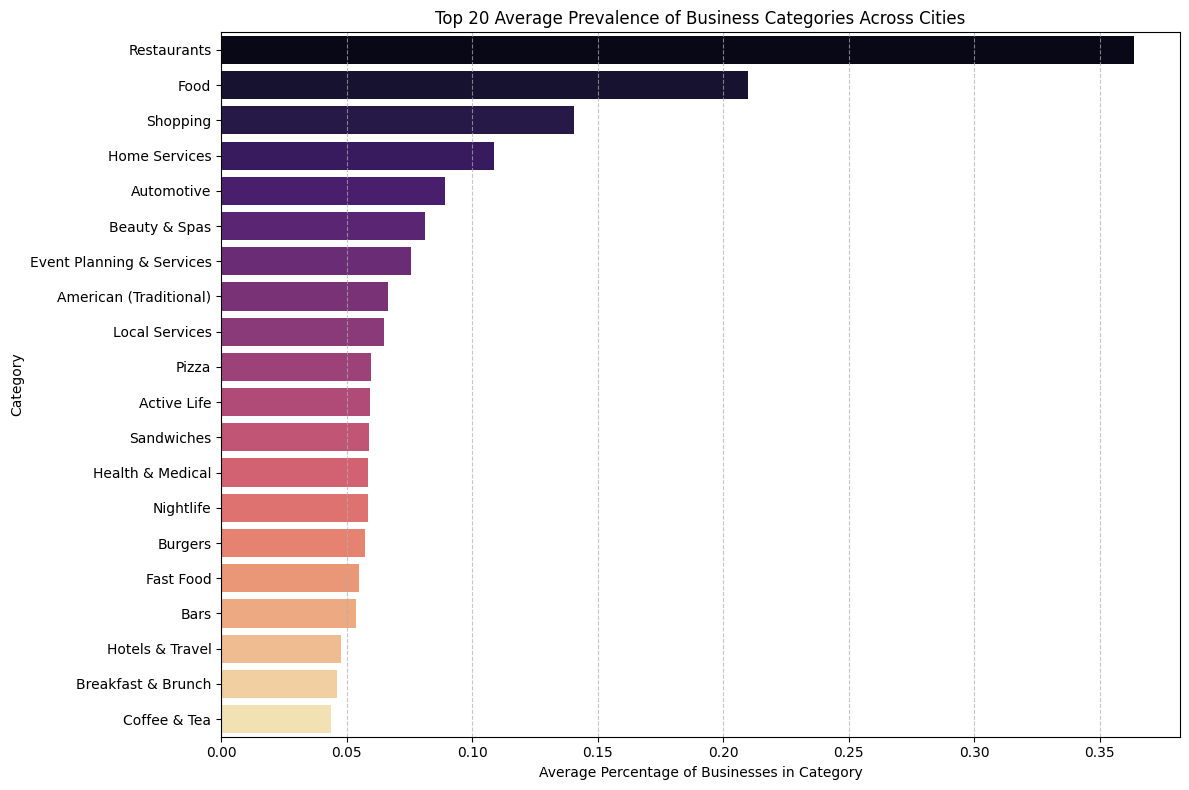

In [ ]:
# category columns (excluding 'city')
category_cols = [col for col in city_category.columns if col.startswith('cat_pct__')]

# Calculate mean percentage for each category across all cities and get the top 20
mean_category_percentages = city_category[category_cols].mean().sort_values(ascending=False).head(20)

plot_data_cats = pd.DataFrame({
    'Category': mean_category_percentages.index.str.replace('cat_pct__', '').str.replace('_', ' '),
    'Average Percentage': mean_category_percentages.values
})

plt.figure(figsize=(12, 8))
sns.barplot(x='Average Percentage', y='Category', data=plot_data_cats, palette='magma', hue='Category', legend=False)
plt.title('Top 20 Average Prevalence of Business Categories Across Cities')
plt.xlabel('Average Percentage of Businesses in Category')
plt.ylabel('Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
colms = []
for col in city_category:
  colms.append(col)

print(colms)

['city', 'cat_pct__Accessories', 'cat_pct__Active_Life', 'cat_pct__American_(New)', 'cat_pct__American_(Traditional)', 'cat_pct__Apartments', 'cat_pct__Arts_&_Crafts', 'cat_pct__Arts_&_Entertainment', 'cat_pct__Asian_Fusion', 'cat_pct__Auto_Parts_&_Supplies', 'cat_pct__Auto_Repair', 'cat_pct__Automotive', 'cat_pct__Bakeries', 'cat_pct__Barbeque', 'cat_pct__Barbers', 'cat_pct__Bars', 'cat_pct__Beauty_&_Spas', 'cat_pct__Beer', 'cat_pct__Breakfast_&_Brunch', 'cat_pct__Burgers', 'cat_pct__Cafes', 'cat_pct__Car_Dealers', 'cat_pct__Caterers', 'cat_pct__Chicken_Wings', 'cat_pct__Chinese', 'cat_pct__Cocktail_Bars', 'cat_pct__Coffee_&_Tea', 'cat_pct__Contractors', 'cat_pct__Convenience_Stores', 'cat_pct__Cosmetic_Dentists', 'cat_pct__Cosmetics_&_Beauty_Supply', 'cat_pct__Day_Spas', 'cat_pct__Delis', 'cat_pct__Dentists', 'cat_pct__Department_Stores', 'cat_pct__Desserts', 'cat_pct__Diners', 'cat_pct__Doctors', 'cat_pct__Drugstores', 'cat_pct__Education', 'cat_pct__Electronics', 'cat_pct__Event_Pl

## Reviews per city

In [ ]:
# review_interactions + business (to map city)
#  captures real users' behaviour

# map business_id → city
biz_city = business[['business_id', 'city']].copy()
interact_city = interact.merge(biz_city, on='business_id', how='left')

In [ ]:
ic = interact_city.value_counts()
ic.head(3)

,,,,count
user_id,business_id,stars,city,
a0DnfD31lNdiBTY2-YBBFA,C6YaSrMAzy3jJqinlFVudw,5,New Orleans,35
I6x-ZBHeCNlMnmtfUVf5lg,PUfhLM-MkjQYZw4ldnJqzQ,5,Reno,32
xWmYN57XXZbg0LOK8WbbFQ,gfLsBY-xsNE9-ktiTvTvGA,5,Tucson,30


In [ ]:
bus_city = interact_city.groupby('city').agg(
    city_avg_rating   = ('stars', 'mean'),
    city_rating_std   = ('stars', 'std'),
    city_n_reviews    = ('stars', 'count'),
    city_n_users      = ('user_id', 'nunique'),
    pct_5stars        = ('stars', lambda x: (x == 5).mean()),  # % perfect ratings
    pct_1stars        = ('stars', lambda x: (x == 1).mean()),  # % negative ratings
).reset_index()

bus_city['city_rating_std'] = bus_city['city_rating_std'].fillna(0)

print(f'Reviews per city shape: {bus_city.shape}')

Reviews per city shape: (1416, 7)


In [ ]:
bus_city.head(2)

,city,city_avg_rating,city_rating_std,city_n_reviews,city_n_users,pct_5stars,pct_1stars
0,AB Edmonton,4.333333,1.632993,6,6,0.833333,0.166667
1,AMBLER,3.000000,1.825742,10,9,0.400000,0.300000


In [ ]:
bus_city[bus_city['city']=='Philadelphia']

,city,city_avg_rating,city_rating_std,city_n_reviews,city_n_users,pct_5stars,pct_1stars
866,Philadelphia,3.785673,1.388208,967552,279857,0.430728,0.123244


In [ ]:
# plot top 10 cities with highest pct_5stars
top_5stars = bus_city.sort_values(by='pct_5stars', ascending=False).head(10)
fig = px.bar(
    top_5stars,
    x='city',
    y='pct_5stars',
    title='Top 10 Cities with Highest Percentage of Perfect Ratings',
    labels={
        'city': 'City',
        'pct_5stars': 'Percentage of Perfect Ratings'
    },
    hover_data={'city': True, 'pct_5stars': ':.2%'}, # Format hover data as percentage
    color_discrete_sequence=px.colors.qualitative.Plotly # Use a nice color sequence
)
fig.update_layout(xaxis_title='City', yaxis_title='Percentage of Perfect Ratings')
fig.show()

## Checkins per city

In [ ]:
# checkin_clean + business
# real popularity doesnt depend of N ratings

checkin_city = checkin.merge(biz_city, on='business_id', how='left')

Checks_in = checkin_city.groupby('city').agg(
    total_checkins    = ('n_checkins', 'sum'),   # total visits
    avg_checkins_biz  = ('n_checkins', 'mean'),
    max_checkins_biz  = ('n_checkins', 'max'),   # most visited business
).reset_index()

print(f'Checkins per city shape: {Checks_in.shape}')

Checkins per city shape: (1301, 4)


In [ ]:
# Top 5 cities with more checkins
top_checkins = Checks_in.sort_values(by='total_checkins', ascending=False).head(5)
fig = px.bar(
    top_checkins,
    x='city',
    y='total_checkins',
    title='Top 5 Cities with Highest Total Checkins',
    labels={
        'city': 'City',
        'total_checkins': 'Total Checkins'
    },
    hover_data={'city': True}, # Format hover data as percentage
    color_discrete_sequence=px.colors.qualitative.Plotly # Use a nice color sequence
)
fig.update_layout(xaxis_title='City', yaxis_title='Total checkins')
fig.show()

In [ ]:
# merge
city_features = bus_per_city.copy()
city_features = city_features.merge(at_per_city, on='city', how='left')
city_features = city_features.merge(city_category, on='city', how='left')
city_features = city_features.merge(bus_city, on='city', how='left')
city_features = city_features.merge(Checks_in, on='city', how='left')

In [ ]:
city_features.isna().sum()

,0
city,0
n_businesses,0
avg_stars,0
median_stars,0
std_stars,590
...,...
pct_5stars,0
pct_1stars,0
total_checkins,115
avg_checkins_biz,115


In [ ]:
city_features = city_features.fillna(0)

In [ ]:
city_features.isna().sum().sum()

np.int64(0)

In [ ]:
city_features.head(2)

,city,n_businesses,avg_stars,median_stars,std_stars,total_reviews,avg_reviews_per_biz,pct_open,avg_n_categories,city_pct_ByAppointmentOnly,...,cat_pct__Women's_Clothing,city_avg_rating,city_rating_std,city_n_reviews,city_n_users,pct_5stars,pct_1stars,total_checkins,avg_checkins_biz,max_checkins_biz
0,AB Edmonton,1,4.5,4.5,0.0,6,6.0,1.0,2.0,0.0,...,0.0,4.333333,1.632993,6,6,0.833333,0.166667,5.0,5.0,5.0
1,AMBLER,1,3.0,3.0,0.0,9,9.0,1.0,4.0,1.0,...,0.0,3.000000,1.825742,10,9,0.400000,0.300000,2.0,2.0,2.0


In [ ]:
print(f'\nCITY FEATURE MATRIX')
print(f'Cities: {city_features.shape[0]:,}')
print(f'Features: {city_features.shape[1] - 1}')
print(f'NaN:      {city_features.isna().sum().sum()}')
print(f'Memoria:  {city_features.memory_usage(deep=True).sum() / 1e6:.1f} MB')

city_features.to_parquet(PROCESSED + 'city_features.parquet', index=False)
print('\nGuardado: city_features.parquet')


CITY FEATURE MATRIX
Cities: 1,416
Features: 161
NaN:      0
Memoria:  1.9 MB

Guardado: city_features.parquet


## PCA

In [6]:
city_features = pd.read_parquet(PROCESSED + 'city_features.parquet')

In [7]:
city_features.shape

(1416, 162)

In [8]:
# PCA ON CITY FEATURES
for col in city_features.columns:
    print(f"Column '{col}': city_features dtype = {city_features[col].dtype}")

Column 'city': city_features dtype = object
Column 'n_businesses': city_features dtype = int64
Column 'avg_stars': city_features dtype = float64
Column 'median_stars': city_features dtype = float64
Column 'std_stars': city_features dtype = float64
Column 'total_reviews': city_features dtype = int64
Column 'avg_reviews_per_biz': city_features dtype = float64
Column 'pct_open': city_features dtype = float64
Column 'avg_n_categories': city_features dtype = float64
Column 'city_pct_ByAppointmentOnly': city_features dtype = float64
Column 'city_pct_BusinessAcceptsCreditCards': city_features dtype = float64
Column 'city_pct_BikeParking': city_features dtype = float64
Column 'city_pct_RestaurantsTakeOut': city_features dtype = float64
Column 'city_pct_RestaurantsDelivery': city_features dtype = float64
Column 'city_pct_Caters': city_features dtype = float64
Column 'city_pct_BusinessParking__garage': city_features dtype = float64
Column 'city_pct_BusinessParking__street': city_features dtype =

only numeric values, we can visualize that the only column which is not going through PCA is 'city'

In [9]:
city_num = city_features.select_dtypes(include=[np.number]).copy()
city_num.shape

(1416, 161)

we make sure there are none missing values

In [10]:
city_num.isna().sum().sum()

np.int64(0)

In [11]:
city_ids = city_features['city']

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(city_num)

In [13]:
print(f'Mean after scaling (~0): {X_scaled.mean():.6f}')
print(f'Std after scaling (~1):  {X_scaled.std():.6f}')

Mean after scaling (~0): -0.000000
Std after scaling (~1):  1.000000


In [14]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

PCA(random_state=42)

In [15]:
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_70 = np.argmax(cumvar >= 0.70) + 1
n_75 = np.argmax(cumvar >= 0.75) + 1
n_80 = np.argmax(cumvar >= 0.80) + 1
n_90 = np.argmax(cumvar >= 0.90) + 1

In [16]:
print(f'Components for 70% variance: {n_70}')
print(f'Components for 75% variance: {n_75}')
print(f'Components for 80% variance: {n_80}')
print(f'Components for 90% variance: {n_90}')
print(f'Total features:              {X_scaled.shape[1]}')


print(f'Reduction ratio (70%):       {1 - n_70/X_scaled.shape[1]:.1%} fewer dimensions')
print(f'Reduction ratio (75%):       {1 - n_75/X_scaled.shape[1]:.1%} fewer dimensions')
print(f'Reduction ratio (80%):       {1 - n_80/X_scaled.shape[1]:.1%} fewer dimensions')
print(f'Reduction ratio (90%):       {1 - n_90/X_scaled.shape[1]:.1%} fewer dimensions')

Components for 70% variance: 51
Components for 75% variance: 59
Components for 80% variance: 69
Components for 90% variance: 94
Total features:              161
Reduction ratio (70%):       68.3% fewer dimensions
Reduction ratio (75%):       63.4% fewer dimensions
Reduction ratio (80%):       57.1% fewer dimensions
Reduction ratio (90%):       41.6% fewer dimensions


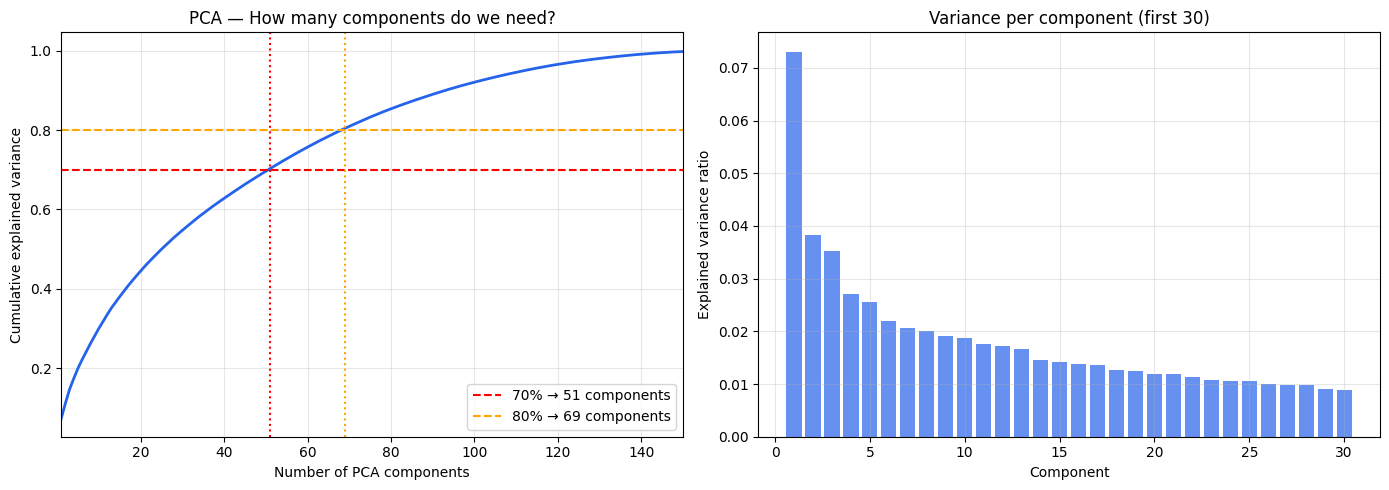


First component explains: 7.3%
Second component explains: 3.8%


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative explained variance
ax1.plot(range(1, len(cumvar)+1), cumvar, linewidth=2, color='#2563EB')
ax1.axhline(0.70, color='red',    linestyle='--', label=f'70% → {n_70} components')
ax1.axhline(0.80, color='orange', linestyle='--', label=f'80% → {n_80} components')
ax1.axvline(n_70, color='red',    linestyle=':')
ax1.axvline(n_80, color='orange', linestyle=':')
ax1.set_xlabel('Number of PCA components')
ax1.set_ylabel('Cumulative explained variance')
ax1.set_title('PCA — How many components do we need?')
ax1.legend()
ax1.set_xlim(1, min(150, X_scaled.shape[1]))
ax1.grid(alpha=0.3)

# Individual component variance (first 30)
ax2.bar(range(1, 31), pca_full.explained_variance_ratio_[:30], color='#2563EB', alpha=0.7)
ax2.set_xlabel('Component')
ax2.set_ylabel('Explained variance ratio')
ax2.set_title('Variance per component (first 30)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f'\nFirst component explains: {pca_full.explained_variance_ratio_[0]:.1%}')
print(f'Second component explains: {pca_full.explained_variance_ratio_[1]:.1%}')

gradual growth there are no visible elbows

In [18]:
for n in [20, 30, 40, 50,70, 75,80, 85,90, 98,100, 116, 200]:
    var = np.sum(pca_full.explained_variance_ratio_[:n])
    print(f'{n:4d} components → {var:.1%} variance')

  20 components → 44.4% variance
  30 components → 54.7% variance
  40 components → 62.8% variance
  50 components → 69.6% variance
  70 components → 80.9% variance
  75 components → 83.3% variance
  80 components → 85.4% variance
  85 components → 87.3% variance
  90 components → 89.0% variance
  98 components → 91.5% variance
 100 components → 92.1% variance
 116 components → 95.8% variance
 200 components → 100.0% variance


PCA reveals that the feature matrix exhibits moderate redundancy with a widely distributed variance structure. Approximately 75% of the variance is retained only after 59 components (out of 161), indicating that no small subset of features dominates the representation.


In [19]:
comparison = pd.DataFrame({
    "Setting": ["Original", "PCA 70%", "PCA 75%", "PCA 80%","PCA 90%"],
    "Dimensions": [X_scaled.shape[1],n_70, n_75, n_80, n_90],
    "Variance Retained": [1.0, 0.70, 0.75, 0.80, 0.90]
})

comparison

,Setting,Dimensions,Variance Retained
0,Original,161,1.00
1,PCA 70%,51,0.70
2,PCA 75%,59,0.75
3,PCA 80%,69,0.80
4,PCA 90%,94,0.90


In [ ]:
# Reduce to 75%
pca = PCA(n_components=n_75, random_state=42)
X_reduced = pca.fit_transform(X_scaled)

print("Reduced shape:", X_reduced.shape)

Reduced shape: (1416, 59)


For clustering (W7), selecting 59 components (75% variance) provides a reasonable trade-off between dimensionality reduction and information retention, while helping mitigate the curse of dimensionality in K-Means.

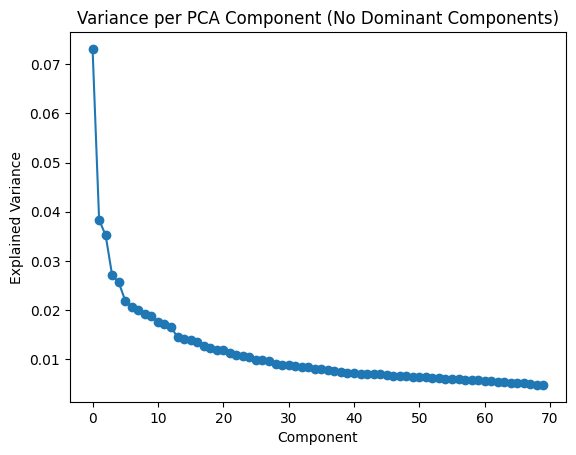

In [20]:
explained = pca_full.explained_variance_ratio_

plt.figure()
plt.plot(explained[:70], marker='o')  # first 60 components
plt.xlabel("Component")
plt.ylabel("Explained Variance")
plt.title("Variance per PCA Component (No Dominant Components)")
plt.show()

The gradual decay of explained variance confirms that no single component dominates the feature space, reflecting the complex and multi-dimensional nature of city characteristics.

In [21]:
loadings = pd.DataFrame(
    pca_full.components_[:5],
    columns=city_num.columns,
    index=[f'PC{i+1}' for i in range(5)]
)

# top contributors PC1
loadings.loc['PC1'].abs().sort_values(ascending=False).head(10)

,PC1
city_pct_RestaurantsGoodForGroups,0.243901
cat_pct__Restaurants,0.241443
city_pct_attire_casual,0.240555
city_pct_RestaurantsTakeOut,0.229425
city_pct_HasTV,0.219491
city_pct_Ambience__casual,0.193463
city_pct_GoodForKids,0.189003
city_pct_OutdoorSeating,0.181135
city_pct_GoodForMeal__dinner,0.178267
city_pct_alcohol_full_bar,0.173296


PC1 is driven by restaurant density / casual / social cities

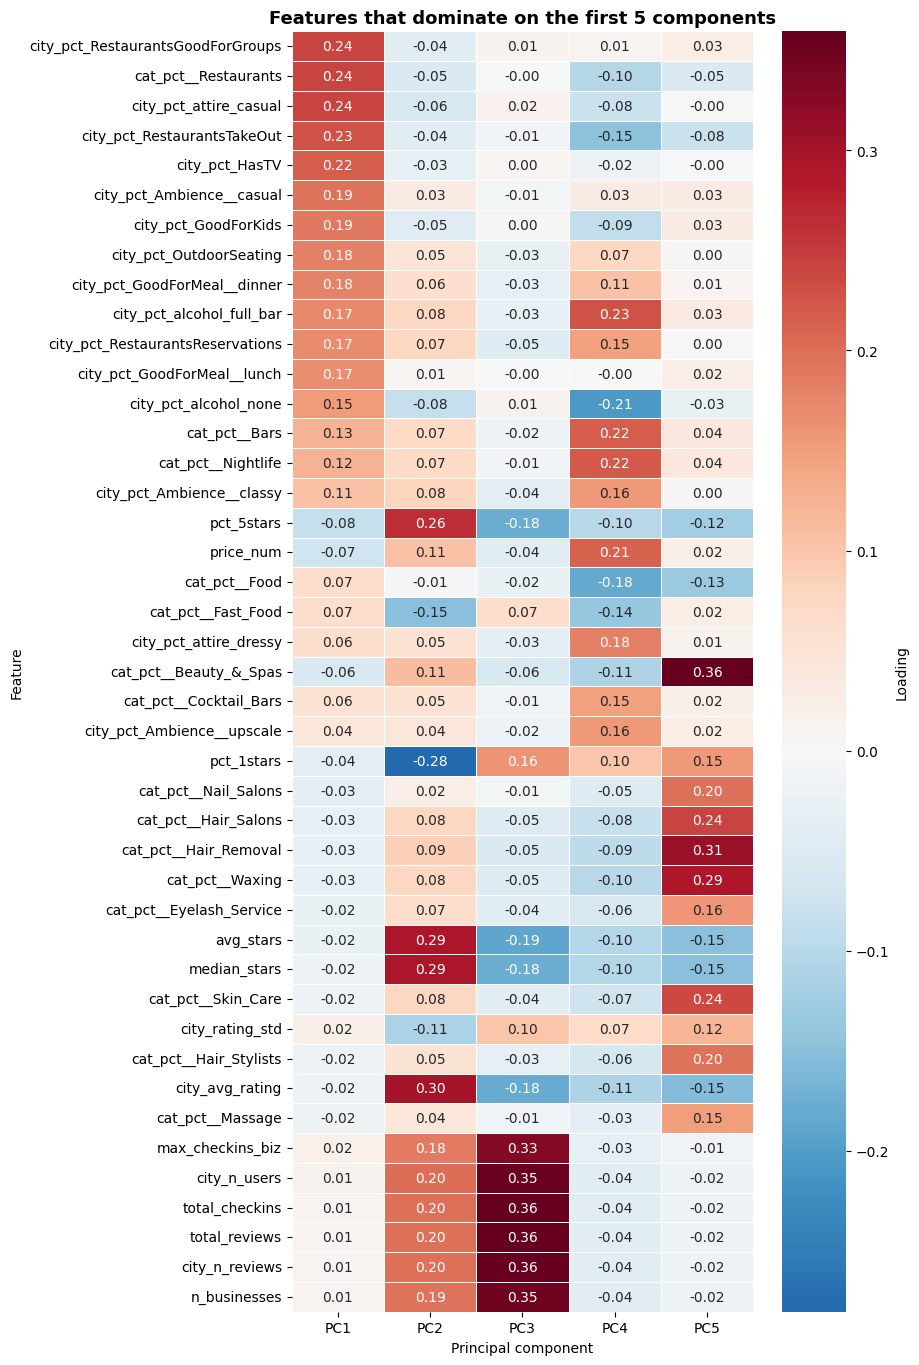

In [24]:
# Top features that contribute to the first 5 principal components
n_pcs_show = 5
n_top_per_pc = 12

top_feats = set()
for i in range(n_pcs_show):
    idx = np.abs(pca_full.components_[i]).argsort()[::-1][:n_top_per_pc]
    top_feats.update(city_num.columns[idx])

top_feats = list(top_feats)
col_idx  = [city_num.columns.get_loc(f) for f in top_feats]

loadings_top = pd.DataFrame(
    pca_full.components_[:n_pcs_show, col_idx].T,
    index=top_feats,
    columns=[f'PC{i+1}' for i in range(n_pcs_show)]
)
# Order by magnitude on PC1
loadings_top = loadings_top.reindex(
    loadings_top['PC1'].abs().sort_values(ascending=False).index
)

plt.figure(figsize=(9, max(8, len(top_feats)*0.32)))
sns.heatmap(loadings_top, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            cbar_kws={'label': 'Loading'}, linewidths=0.4)
plt.title('Features that dominate on the first 5 components',
          fontsize=13, fontweight='bold')
plt.xlabel('Principal component')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

First, PC1 captures an aggregate construct of approximately 15 gastronomic-social features that move together none dominates, which explains why the variance is gradually distributed and why we need 59 components for 75%. Second, PC4 revealed a nontrivial latent dimension: within the gastronomic axis, it separates bar/formal dining culture from family/take-out culture. For clustering in W7, this suggests that cities with high PC1 scores can be grouped into distinct sub-clusters based on their PC4 scores 'adult foodie' vs. 'family foodie' cities.

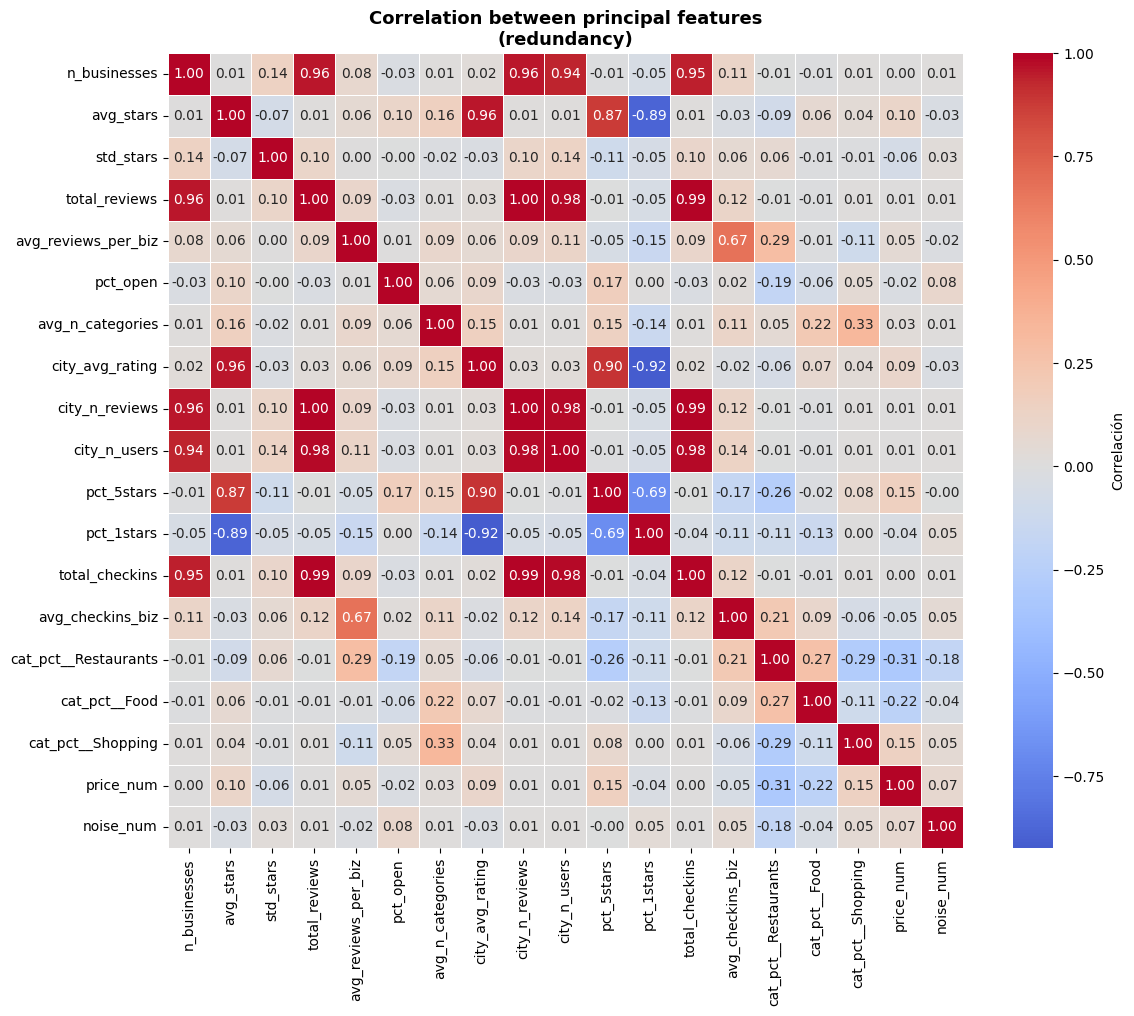

In [43]:
# Correlation between keys
key_features = [
    'n_businesses', 'avg_stars', 'std_stars', 'total_reviews',
    'avg_reviews_per_biz', 'pct_open', 'avg_n_categories',
    'city_avg_rating', 'city_n_reviews', 'city_n_users',
    'pct_5stars', 'pct_1stars', 'total_checkins', 'avg_checkins_biz',
    'cat_pct__Restaurants', 'cat_pct__Food', 'cat_pct__Shopping',
    'price_num', 'noise_num'
]
key_features = [f for f in key_features if f in city_features.columns]

corr = city_features[key_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlación'})
plt.title('Correlation between principal features\n(redundancy)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

While the correlation matrix reveals strong redundancy within specific feature groups (e.g., activity and rating variables), the dataset is not globally redundant. Instead, it exhibits a heterogeneous structure, where different feature blocks capture distinct aspects of city characteristics. As a result, variance is distributed across multiple dimensions, leading to a gradual accumulation of explained variance in PCA rather than a sharp drop-off

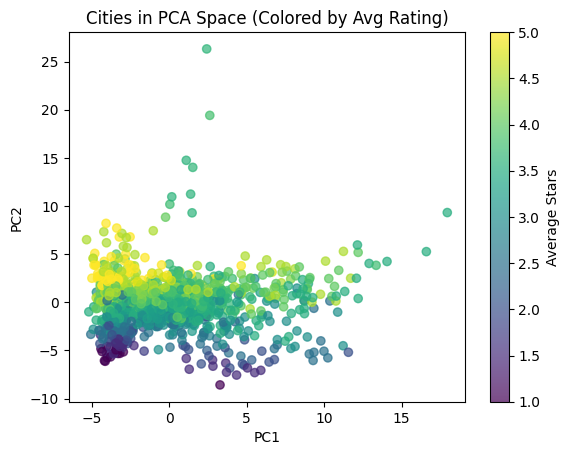

In [22]:
# 2D projection
pca_2 = PCA(n_components=2, random_state=42)
X_2d = pca_2.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_2d[:,0], X_2d[:,1],
            c=city_features['avg_stars'],
            alpha=0.7)

plt.colorbar(label="Average Stars")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cities in PCA Space (Colored by Avg Rating)")
plt.show()

The PCA projection shows that average rating is not strongly aligned with the primary structural dimension (PC1), which is dominated by restaurant-related features. This suggests that city ratings depend on additional factors beyond business composition.

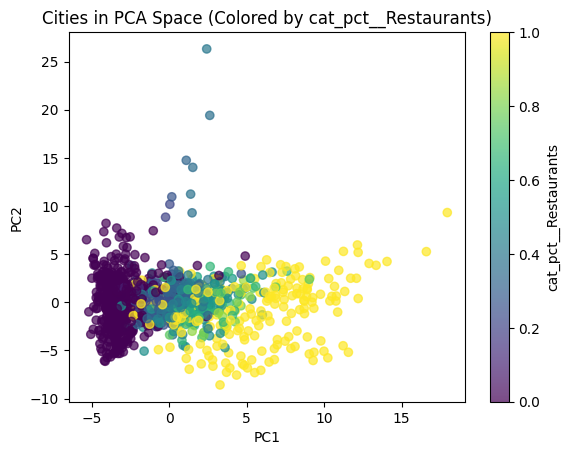

In [23]:
plt.figure()
plt.scatter(X_2d[:,0], X_2d[:,1],
            c=city_features['cat_pct__Restaurants'],
            alpha=0.7)

plt.colorbar(label="cat_pct__Restaurants")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cities in PCA Space (Colored by cat_pct__Restaurants)")
plt.show()

cities which have at least 40% of restaurants as businesses are cities with a more social personlity

The feature space is high-dimensional and does not collapse into a few dominant components, indicating that city representation is complex and multi-factorial.

In [38]:
# order city by most n_users
city_featuresord = city_features.sort_values(by='city_n_users', ascending=False)

In [39]:
city_featuresord.head(8)

,city,n_businesses,avg_stars,median_stars,std_stars,total_reviews,avg_reviews_per_biz,pct_open,avg_n_categories,city_pct_ByAppointmentOnly,...,cat_pct__Women's_Clothing,city_avg_rating,city_rating_std,city_n_reviews,city_n_users,pct_5stars,pct_1stars,total_checkins,avg_checkins_biz,max_checkins_biz
866,Philadelphia,14569,3.623035,4.0,0.960691,936240,64.262475,0.723591,4.380465,0.099595,...,0.015993,3.785673,1.388208,967552,279857,0.430728,0.123244,1838206.0,142.585014,52144.0
758,New Orleans,6209,3.822677,4.0,0.873458,621361,100.074247,0.748752,4.532292,0.073764,...,0.023031,3.944693,1.328426,635364,245356,0.488363,0.099437,1486495.0,253.365434,40109.0
745,Nashville,6971,3.637785,4.0,0.986197,441053,63.269689,0.774351,4.645245,0.102568,...,0.024243,3.818166,1.432685,451571,180432,0.474446,0.133777,817283.0,132.289252,31168.0
1157,Tampa,9050,3.583315,4.0,1.007798,439506,48.564199,0.797680,4.561547,0.116354,...,0.012928,3.753065,1.499923,454889,165718,0.475665,0.161437,918203.0,114.703685,37518.0
1007,Santa Barbara,3829,4.051449,4.0,0.879772,262853,68.647950,0.788718,4.747715,0.201880,...,0.025333,4.003434,1.389320,269630,130351,0.557916,0.114891,507626.0,169.831382,6528.0
1210,Tucson,9250,3.594919,3.5,0.982255,387254,41.865297,0.814378,4.352541,0.126486,...,0.011676,3.700897,1.532508,404880,121312,0.470026,0.173234,772140.0,97.987310,10089.0
926,Reno,5935,3.761584,4.0,0.977601,334610,56.379107,0.802359,4.526201,0.167818,...,0.014659,3.748280,1.533467,351573,118339,0.494188,0.171262,712312.0,139.751226,13420.0
511,Indianapolis,7540,3.579708,4.0,0.996452,349228,46.316711,0.781698,4.441379,0.079576,...,0.013926,3.823646,1.414526,361489,104810,0.461322,0.132073,886001.0,128.127404,21487.0


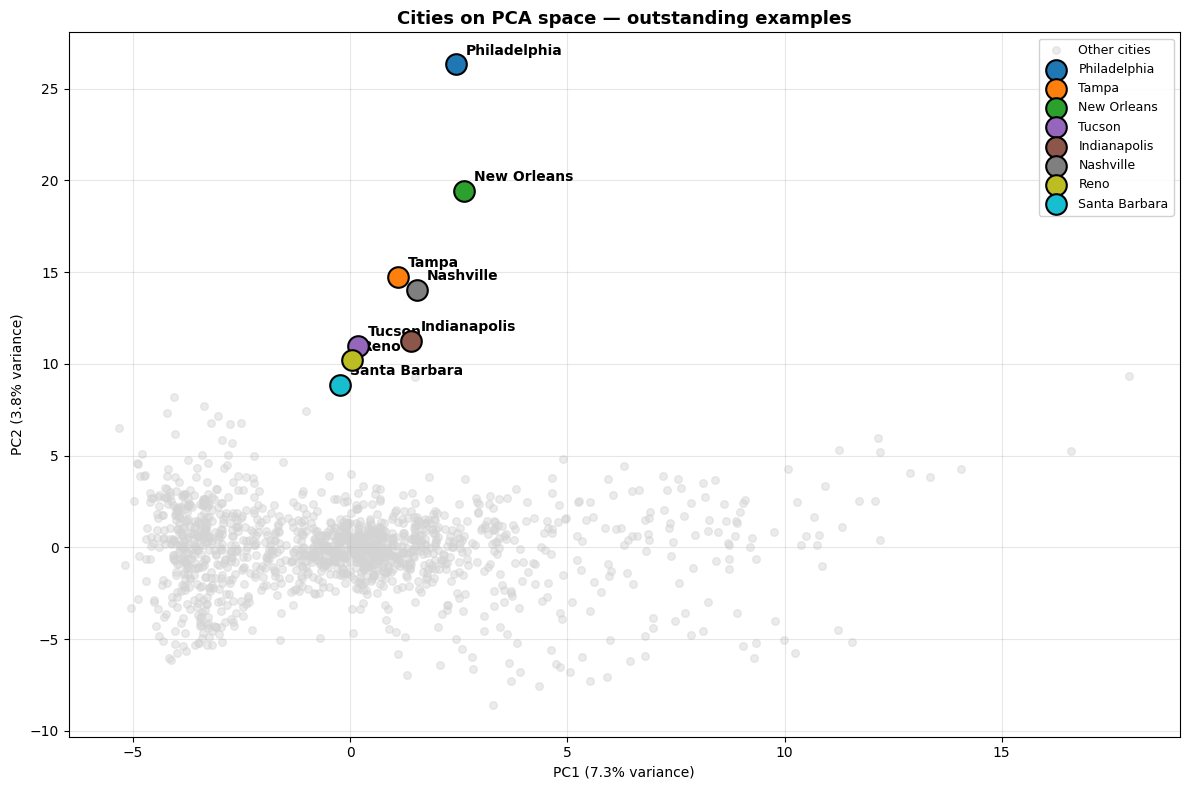

In [40]:
# 2D Proyection with most emblematic cities highlighted
plt.figure(figsize=(12, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c='lightgray', alpha=0.45, s=30,
            label='Other cities')

cities_to_highlight = ['Philadelphia', 'Tampa', 'New Orleans', 'Tucson',
                       'Indianapolis', 'Nashville', 'Reno', 'Santa Barbara']
colors = plt.cm.tab10(np.linspace(0, 1, len(cities_to_highlight)))

for city, color in zip(cities_to_highlight, colors):
    mask = city_features['city'].values == city
    if mask.any():
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[color], s=220,
                    edgecolor='black', linewidth=1.5, label=city, zorder=5)
        plt.annotate(city, (X_2d[mask, 0][0], X_2d[mask, 1][0]),
                     xytext=(7, 7), textcoords='offset points',
                     fontsize=10, fontweight='bold')

plt.xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Cities on PCA space — outstanding examples',
          fontsize=13, fontweight='bold')
plt.legend(loc='best', framealpha=0.9, fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The 2D PCA projection shows most cities clustered tightly near the origin, while highlighted cities sit notably high on PC2. Philadelphia leads, followed by New Orleans, with Tampa, Nashville, Indianapolis, Tucson, Reno and Santa Barbara grouped lower. Their elevated PC2 values reflect richer, denser business ecosystems compared to the long-tail of smaller cities. PC1 explains only 7.3% of variance, confirming variance is distributed across many dimensions.

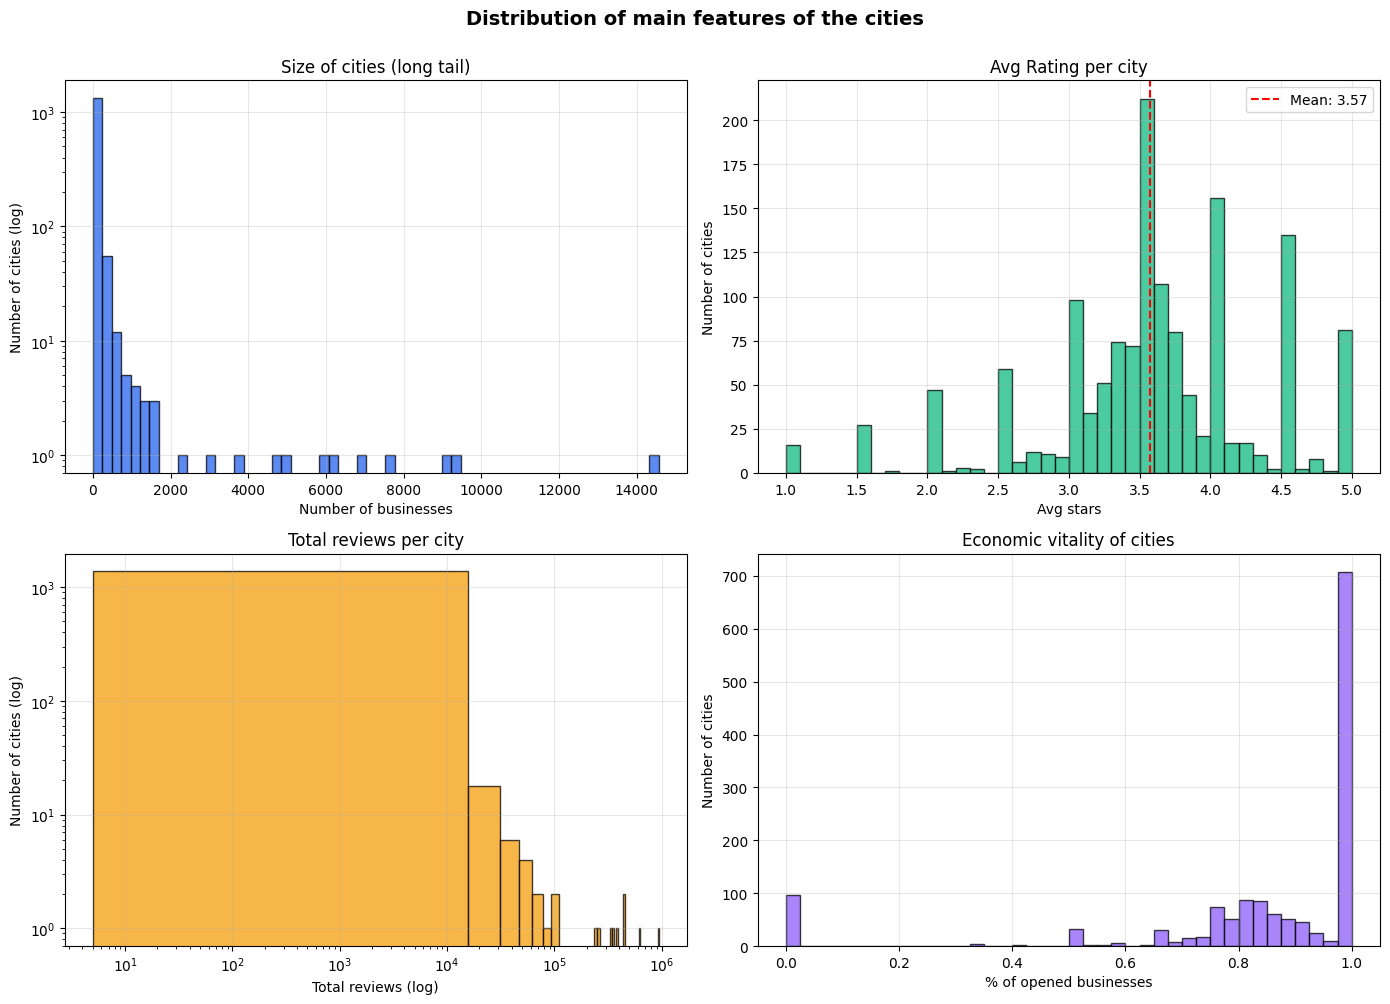

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# size of cities (long tail → log)
axes[0, 0].hist(city_features['n_businesses'], bins=60,
                color='#2563EB', edgecolor='black', alpha=0.75)
axes[0, 0].set_yscale('log')
axes[0, 0].set_xlabel('Number of businesses')
axes[0, 0].set_ylabel('Number of cities (log)')
axes[0, 0].set_title('Size of cities (long tail)')
axes[0, 0].grid(alpha=0.3)

# mean quality
axes[0, 1].hist(city_features['avg_stars'], bins=40,
                color='#10B981', edgecolor='black', alpha=0.75)
mean_stars = city_features['avg_stars'].mean()
axes[0, 1].axvline(mean_stars, color='red', linestyle='--',
                   label=f'Mean: {mean_stars:.2f}')
axes[0, 1].set_xlabel('Avg stars')
axes[0, 1].set_ylabel('Number of cities')
axes[0, 1].set_title('Avg Rating per city')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Total review
axes[1, 0].hist(city_features['total_reviews'].clip(lower=1), bins=60,
                color='#F59E0B', edgecolor='black', alpha=0.75)
axes[1, 0].set_xscale('log'); axes[1, 0].set_yscale('log')
axes[1, 0].set_xlabel('Total reviews (log)')
axes[1, 0].set_ylabel('Number of cities (log)')
axes[1, 0].set_title('Total reviews per city')
axes[1, 0].grid(alpha=0.3)

# % of opened businesses
axes[1, 1].hist(city_features['pct_open'], bins=40,
                color='#8B5CF6', edgecolor='black', alpha=0.75)
axes[1, 1].set_xlabel('% of opened businesses')
axes[1, 1].set_ylabel('Number of cities')
axes[1, 1].set_title('Economic vitality of cities')
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Distribution of main features of the cities',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

The distribution panel exposes strong heterogeneity across cities. City size and total reviews follow extreme longtail patterns, spanning several orders of magnitude. Average ratings concentrate around 3.57, with peaks at round values (3.5, 4.0, 4.5, 5.0) reflecting smallcity quantization. Most cities show 80–100% of businesses open, though a notable group sits near 0%. This heterogeneity justifies standardization before PCA to prevent scaledriven dominance.

In [ ]:
pca_df = pd.DataFrame(
    X_reduced,
    columns=[f'PC{i+1}' for i in range(X_reduced.shape[1])]
)

#keep city identifier
if city_ids is not None:
    pca_df.insert(0, 'city', city_ids.values)

pca_df.to_parquet("city_features_pca.parquet", index=False)

In [ ]:
import joblib

joblib.dump(pca, "pca_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

## External data (not used in w5 & w7)

In [ ]:
EDATA = '/content/drive/MyDrive/yelp_dataset/data/'

In [ ]:
df = pd.read_parquet('/content/drive/MyDrive/yelp_dataset/dataset_tourism_europe_peru.parquet')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363 entries, 0 to 362
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   business_id                   363 non-null    object 
 1   name                          363 non-null    object 
 2   country                       363 non-null    object 
 3   region                        363 non-null    object 
 4   city                          363 non-null    object 
 5   latitude                      363 non-null    float64
 6   longitude                     363 non-null    float64
 7   primary_category              363 non-null    object 
 8   city_vibe                     363 non-null    object 
 9   description                   363 non-null    object 
 10  climate_type                  363 non-null    object 
 11  best_season                   363 non-null    object 
 12  language                      363 non-null    object 
 13  custo

In [ ]:
df.head(2)

,business_id,name,country,region,city,latitude,longitude,primary_category,city_vibe,description,...,attr__Ambience__romantic,attr__Ambience__casual,attr__Ambience__adventurous,attr__RestaurantsPriceRange2,stars,review_count,hours__open_days,is_open,data_source,description_source
0,PE_LIM_00001,Larco Museum,Peru,Lima,Lima,-12.017819,-77.041959,Museums,Cultural,"Larco Museum is a remarkable museums in Lima, ...",...,False,False,False,2,4.3,3438,6,1,custom_enriched_v2,template
1,PE_LIM_00002,Huaca Pucllana,Peru,Lima,Lima,-12.041451,-77.026071,Landmarks & Historical Buildings,Historical,Huaca Pucllana is a remarkable landmarks & his...,...,True,False,False,2,4.7,3132,5,1,custom_enriched_v2,template


In [ ]:
# get n_categories from counting attr_ more than to 0 (true)
df['n_categories'] = (df[df.columns[df.columns.str.startswith('attr__')]] == True).sum(axis=1)

In [ ]:
df.head(2)

,business_id,name,country,region,city,latitude,longitude,primary_category,city_vibe,description,...,attr__Ambience__casual,attr__Ambience__adventurous,attr__RestaurantsPriceRange2,stars,review_count,hours__open_days,is_open,data_source,description_source,n_categories
0,PE_LIM_00001,Larco Museum,Peru,Lima,Lima,-12.017819,-77.041959,Museums,Cultural,"Larco Museum is a remarkable museums in Lima, ...",...,False,False,2,4.3,3438,6,1,custom_enriched_v2,template,2
1,PE_LIM_00002,Huaca Pucllana,Peru,Lima,Lima,-12.041451,-77.026071,Landmarks & Historical Buildings,Historical,Huaca Pucllana is a remarkable landmarks & his...,...,False,False,2,4.7,3132,5,1,custom_enriched_v2,template,3


In [ ]:
print(f'Tourism df shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nCities on tourism: {df["city"].nunique()}')
print(df['city'].value_counts().head(10))

Tourism df shape: (363, 29)

Columns: ['business_id', 'name', 'country', 'region', 'city', 'latitude', 'longitude', 'primary_category', 'city_vibe', 'description', 'climate_type', 'best_season', 'language', 'customs_note', 'local_festival', 'safety_index', 'attr__Ambience__touristy', 'attr__Ambience__classy', 'attr__Ambience__romantic', 'attr__Ambience__casual', 'attr__Ambience__adventurous', 'attr__RestaurantsPriceRange2', 'stars', 'review_count', 'hours__open_days', 'is_open', 'data_source', 'description_source', 'n_categories']

Cities on tourism: 113
city
Lima         6
Cusco        6
Barcelona    6
Madrid       6
Rome         6
Paris        6
Berlin       6
Lisbon       6
London       6
Vienna       6
Name: count, dtype: int64


In [ ]:
# Numéricas: promedio por ciudad
tourism_per_city = df.groupby('city').agg(
    n_businesses     = ('business_id', 'count'),
    avg_stars         = ('stars', 'mean'),
    median_stars      = ('stars', 'median'),
    std_stars         = ('stars', 'std'),
    total_reviews     = ('review_count', 'sum'),
    avg_reviews_per_biz = ('review_count', 'mean'),
    pct_open          = ('is_open', 'mean'),
    avg_n_categories  = ('n_categories', 'mean')
).reset_index()


In [ ]:
tourism_per_city.isna().sum()

,0
city,0
n_businesses,0
avg_stars,0
median_stars,0
std_stars,6
total_reviews,0
avg_reviews_per_biz,0
pct_open,0
avg_n_categories,0


In [ ]:
tourism_per_city.fillna(0, inplace=True)

In [ ]:
tourism_per_city.isna().sum().sum()

np.int64(0)

In [ ]:
tourism_per_city.head(2)

,city,n_businesses,avg_stars,median_stars,std_stars,total_reviews,avg_reviews_per_biz,pct_open,avg_n_categories
0,Aarhus,3,4.333333,4.4,0.11547,31834,10611.333333,1.0,2.333333
1,Agrigento,1,4.900000,4.9,0.00000,13949,13949.000000,1.0,3.000000


In [ ]:
df.shape

(363, 29)

In [ ]:
tourism_per_city.shape

(113, 9)

###reviews per city on external data

In [ ]:
rev_city = df.groupby('city').agg(
    city_avg_rating   = ('stars', 'mean'),
    city_rating_std   = ('stars', 'std'),
    city_n_reviews    = ('stars', 'count'),
    pct_5stars        = ('stars', lambda x: (x == 5).mean()),  # % perfect ratings
    pct_1stars        = ('stars', lambda x: (x == 1).mean()),  # % negative ratings
).reset_index()

rev_city['city_rating_std'] = rev_city['city_rating_std'].fillna(0)

print(f'Reviews per city shape: {rev_city.shape}')

Reviews per city shape: (113, 6)


In [ ]:
# add new agg to df
df_feat = tourism_per_city.copy()
df_feat = df_feat.merge(rev_city, on='city', how='left')

In [ ]:
df_feat.head(2)

,city,n_businesses,avg_stars,median_stars,std_stars,total_reviews,avg_reviews_per_biz,pct_open,avg_n_categories,city_avg_rating,city_rating_std,city_n_reviews,pct_5stars,pct_1stars
0,Aarhus,3,4.333333,4.4,0.11547,31834,10611.333333,1.0,2.333333,4.333333,0.11547,3,0.0,0.0
1,Agrigento,1,4.900000,4.9,0.00000,13949,13949.000000,1.0,3.000000,4.900000,0.00000,1,0.0,0.0


In [ ]:
df_feat.shape

(113, 14)

We add other feats(mean) that already exist on the extra data

In [ ]:
attr_city2 = [c for c in df.columns if c.startswith('attr__')
             and df[c].dtype == 'bool']

In [ ]:
# mean per city: ex."40% of businesses on this city have a romantic ambience"
at_per_city = df.groupby('city')[attr_city2].mean().reset_index()

# rename for clarity
at_per_city.columns = ['city'] + ['city_pct_' + c.replace('attr__', '')
                               for c in attr_city2]

print(f'Attributes per city shape: {at_per_city.shape}')

Attributes per city shape: (113, 6)


In [ ]:
df_feat = df_feat.merge(at_per_city, on='city', how='left')

In [ ]:
at_per_city.head()

,city,city_pct_Ambience__touristy,city_pct_Ambience__classy,city_pct_Ambience__romantic,city_pct_Ambience__casual,city_pct_Ambience__adventurous
0,Aarhus,1.000000,1.000000,0.333333,0.000000,0.000000
1,Agrigento,1.000000,1.000000,1.000000,0.000000,0.000000
2,Aguas Calientes,0.000000,0.000000,0.000000,1.000000,1.000000
3,Amalfi Coast,0.333333,0.333333,0.333333,0.666667,0.666667
4,Amsterdam,0.800000,0.800000,0.600000,0.200000,0.200000


In [ ]:
df_feat.head()

,city,n_businesses,avg_stars,median_stars,std_stars,total_reviews,avg_reviews_per_biz,pct_open,avg_n_categories,city_avg_rating,city_rating_std,city_n_reviews,pct_5stars,pct_1stars,city_pct_Ambience__touristy,city_pct_Ambience__classy,city_pct_Ambience__romantic,city_pct_Ambience__casual,city_pct_Ambience__adventurous
0,Aarhus,3,4.333333,4.40,0.115470,31834,10611.333333,1.0,2.333333,4.333333,0.115470,3,0.0,0.0,1.000000,1.000000,0.333333,0.000000,0.000000
1,Agrigento,1,4.900000,4.90,0.000000,13949,13949.000000,1.0,3.000000,4.900000,0.000000,1,0.0,0.0,1.000000,1.000000,1.000000,0.000000,0.000000
2,Aguas Calientes,2,4.550000,4.55,0.212132,17529,8764.500000,1.0,2.000000,4.550000,0.212132,2,0.0,0.0,0.000000,0.000000,0.000000,1.000000,1.000000
3,Amalfi Coast,3,4.500000,4.60,0.458258,54872,18290.666667,1.0,2.333333,4.500000,0.458258,3,0.0,0.0,0.333333,0.333333,0.333333,0.666667,0.666667
4,Amsterdam,5,4.260000,4.10,0.364692,42009,8401.800000,1.0,2.800000,4.260000,0.364692,5,0.0,0.0,0.800000,0.800000,0.600000,0.200000,0.200000


In [ ]:
for col in city_features.columns:
    if col not in df_feat.columns:
        print(col)

city_pct_ByAppointmentOnly
city_pct_BusinessAcceptsCreditCards
city_pct_BikeParking
city_pct_RestaurantsTakeOut
city_pct_RestaurantsDelivery
city_pct_Caters
city_pct_BusinessParking__garage
city_pct_BusinessParking__street
city_pct_BusinessParking__validated
city_pct_BusinessParking__lot
city_pct_BusinessParking__valet
city_pct_WheelchairAccessible
city_pct_OutdoorSeating
city_pct_HasTV
city_pct_RestaurantsReservations
city_pct_GoodForKids
city_pct_RestaurantsGoodForGroups
city_pct_Ambience__intimate
city_pct_Ambience__hipster
city_pct_Ambience__divey
city_pct_Ambience__trendy
city_pct_Ambience__upscale
city_pct_GoodForMeal__dessert
city_pct_GoodForMeal__latenight
city_pct_GoodForMeal__lunch
city_pct_GoodForMeal__dinner
city_pct_GoodForMeal__brunch
city_pct_GoodForMeal__breakfast
price_num
noise_num
city_pct_wifi_free
city_pct_wifi_no
city_pct_wifi_paid
city_pct_alcohol_beer_and_wine
city_pct_alcohol_full_bar
city_pct_alcohol_none
city_pct_attire_casual
city_pct_attire_dressy
city_pct_

In [ ]:
df_feat.shape

(113, 19)

In [ ]:
df_feat.head()

,city,n_businesses,avg_stars,median_stars,std_stars,total_reviews,avg_reviews_per_biz,pct_open,avg_n_categories,city_avg_rating,city_rating_std,city_n_reviews,pct_5stars,pct_1stars,city_pct_Ambience__touristy,city_pct_Ambience__classy,city_pct_Ambience__romantic,city_pct_Ambience__casual,city_pct_Ambience__adventurous
0,Aarhus,3,4.333333,4.40,0.115470,31834,10611.333333,1.0,2.333333,4.333333,0.115470,3,0.0,0.0,1.000000,1.000000,0.333333,0.000000,0.000000
1,Agrigento,1,4.900000,4.90,0.000000,13949,13949.000000,1.0,3.000000,4.900000,0.000000,1,0.0,0.0,1.000000,1.000000,1.000000,0.000000,0.000000
2,Aguas Calientes,2,4.550000,4.55,0.212132,17529,8764.500000,1.0,2.000000,4.550000,0.212132,2,0.0,0.0,0.000000,0.000000,0.000000,1.000000,1.000000
3,Amalfi Coast,3,4.500000,4.60,0.458258,54872,18290.666667,1.0,2.333333,4.500000,0.458258,3,0.0,0.0,0.333333,0.333333,0.333333,0.666667,0.666667
4,Amsterdam,5,4.260000,4.10,0.364692,42009,8401.800000,1.0,2.800000,4.260000,0.364692,5,0.0,0.0,0.800000,0.800000,0.600000,0.200000,0.200000


In [ ]:
# verify cols in df_feat are the same data type
for col in df_feat.columns:
    if col in city_features.columns:
        print(f"Column '{col}': df_feat dtype = {df_feat[col].dtype}, city_features dtype = {city_features[col].dtype}")

Column 'city': df_feat dtype = object, city_features dtype = object
Column 'n_businesses': df_feat dtype = int64, city_features dtype = int64
Column 'avg_stars': df_feat dtype = float64, city_features dtype = float64
Column 'median_stars': df_feat dtype = float64, city_features dtype = float64
Column 'std_stars': df_feat dtype = float64, city_features dtype = float64
Column 'total_reviews': df_feat dtype = int64, city_features dtype = int64
Column 'avg_reviews_per_biz': df_feat dtype = float64, city_features dtype = float64
Column 'pct_open': df_feat dtype = float64, city_features dtype = float64
Column 'avg_n_categories': df_feat dtype = float64, city_features dtype = float64
Column 'city_avg_rating': df_feat dtype = float64, city_features dtype = float64
Column 'city_rating_std': df_feat dtype = float64, city_features dtype = float64
Column 'city_n_reviews': df_feat dtype = int64, city_features dtype = int64
Column 'pct_5stars': df_feat dtype = float64, city_features dtype = float64


In [ ]:
df_feat.shape

(113, 19)

In [ ]:
df_feat_dum = df_feat.copy()

In [ ]:
df_feat_dum.isna().sum()

,0
city,0
n_businesses,0
avg_stars,0
median_stars,0
std_stars,0
total_reviews,0
avg_reviews_per_biz,0
pct_open,0
avg_n_categories,0
city_avg_rating,0


In [ ]:
for col in city_features.columns:
    if col not in df_feat_dum.columns:
    # fill with 0s for other data we do not have
      df_feat_dum[col] = 0

In [ ]:
df_feat_dum.head()

,city,n_businesses,avg_stars,median_stars,std_stars,total_reviews,avg_reviews_per_biz,pct_open,avg_n_categories,city_avg_rating,...,cat_pct__Trainers,cat_pct__Venues_&_Event_Spaces,cat_pct__Veterinarians,cat_pct__Waxing,cat_pct__Wine_&_Spirits,cat_pct__Women's_Clothing,city_n_users,total_checkins,avg_checkins_biz,max_checkins_biz
0,Aarhus,3,4.333333,4.40,0.115470,31834,10611.333333,1.0,2.333333,4.333333,...,0,0,0,0,0,0,0,0,0,0
1,Agrigento,1,4.900000,4.90,0.000000,13949,13949.000000,1.0,3.000000,4.900000,...,0,0,0,0,0,0,0,0,0,0
2,Aguas Calientes,2,4.550000,4.55,0.212132,17529,8764.500000,1.0,2.000000,4.550000,...,0,0,0,0,0,0,0,0,0,0
3,Amalfi Coast,3,4.500000,4.60,0.458258,54872,18290.666667,1.0,2.333333,4.500000,...,0,0,0,0,0,0,0,0,0,0
4,Amsterdam,5,4.260000,4.10,0.364692,42009,8401.800000,1.0,2.800000,4.260000,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
city_features.head()

,city,n_businesses,avg_stars,median_stars,std_stars,total_reviews,avg_reviews_per_biz,pct_open,avg_n_categories,city_pct_ByAppointmentOnly,...,cat_pct__Women's_Clothing,city_avg_rating,city_rating_std,city_n_reviews,city_n_users,pct_5stars,pct_1stars,total_checkins,avg_checkins_biz,max_checkins_biz
0,AB Edmonton,1,4.500000,4.5,0.000000,6,6.000000,1.000000,2.000000,0.00000,...,0.000000,4.333333,1.632993,6,6,0.833333,0.166667,5.0,5.000000,5.0
1,AMBLER,1,3.000000,3.0,0.000000,9,9.000000,1.000000,4.000000,1.00000,...,0.000000,3.000000,1.825742,10,9,0.400000,0.300000,2.0,2.000000,2.0
2,ARDMORE,1,3.000000,3.0,0.000000,8,8.000000,1.000000,4.000000,0.00000,...,0.000000,3.000000,1.772811,8,8,0.250000,0.375000,12.0,12.000000,12.0
3,AVON,1,3.500000,3.5,0.000000,24,24.000000,0.000000,4.000000,0.00000,...,0.000000,3.416667,1.471960,24,24,0.291667,0.166667,37.0,37.000000,37.0
4,Abington,169,3.550296,3.5,0.999472,4829,28.573964,0.804734,4.248521,0.12426,...,0.011834,3.458971,1.621949,5033,3695,0.417445,0.225909,5693.0,40.091549,545.0


In [ ]:
# Identify the column(s) present in df_feat_dum but not in city_features
extra_cols = [col for col in df_feat_dum.columns if col not in city_features.columns]

if extra_cols:
    print(f"Column(s) in df_feat_dum but not in city_features: {extra_cols}")
else:
    print("No extra columns found in df_feat_dum compared to city_features.")

Column(s) in df_feat_dum but not in city_features: ['city_pct_Ambience__adventurous']


The correlation heatmap reveals three latent dimensions in the city features. A size-activity cluster (n_businesses, total_reviews, city_n_users, total_checkins) shows correlations of 0.94–0.99, indicating strong redundancy. A quality axis links avg_stars, city_avg_rating and pct_5stars (~0.87–0.96), opposing pct_1stars (-0.89). Most other features remain uncorrelated, justifying PCA for dimensionality reduction.

In [ ]:
city_features['city_pct_Ambience__adventurous']=0

In [ ]:
city_features.shape

(1416, 163)

In [ ]:
df_feat_dum.shape

(113, 163)

In [ ]:
df_feat_dum.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Columns: 163 entries, city to max_checkins_biz
dtypes: float64(15), int64(147), object(1)
memory usage: 144.0+ KB


In [ ]:
# concat city_features with df_feat_dum
city_features_extra = pd.concat([city_features, df_feat_dum], axis=0)

In [ ]:
city_features_extra.shape

(1529, 163)

In [ ]:
# review which cities of extra data already exist on city_features
city_features_extra['city_lower'] = city_features_extra['city'].str.lower().str.strip()
city_features['city_lower'] = city_features['city'].str.lower().str.strip()

/tmp/ipykernel_10903/1451896853.py:2: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



In [ ]:
df_feat_dum['city_lower'] = df_feat_dum['city'].str.lower().str.strip()
common_cities = pd.merge(city_features[['city_lower']], df_feat_dum[['city_lower']], on='city_lower', how='inner')
print(f'Number of common cities: {common_cities.shape[0]}')
print('Common cities:')
display(common_cities)

Number of common cities: 7
Common cities:


/tmp/ipykernel_10903/2193735874.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



,city_lower
0,berlin
1,colmar
2,colmar
3,dublin
4,florence
5,lima
6,valencia


In [ ]:
# city_features_extra.drop(columns=['city_lower'], inplace=True)

In [ ]:
dropped_rows = city_features[
    city_features["city_lower"].isin(common_cities["city_lower"])
]

In [ ]:
dropped_rows

,city,n_businesses,avg_stars,median_stars,std_stars,total_reviews,avg_reviews_per_biz,pct_open,avg_n_categories,city_pct_ByAppointmentOnly,...,city_rating_std,city_n_reviews,city_n_users,pct_5stars,pct_1stars,total_checkins,avg_checkins_biz,max_checkins_biz,city_pct_Ambience__adventurous,city_lower
75,Berlin,99,3.565657,3.5,0.960034,2235,22.575758,0.878788,4.535354,0.040404,...,1.559691,2321,1810,0.491598,0.184403,2928.0,35.277108,284.0,0,berlin
138,COLMAR,1,5.000000,5.0,0.000000,5,5.000000,1.000000,4.000000,0.000000,...,0.000000,5,5,1.000000,0.000000,1.0,1.000000,1.0,0,colmar
216,Colmar,45,3.488889,3.5,0.991377,1147,25.488889,0.866667,4.933333,0.088889,...,1.672107,1197,1056,0.478697,0.233918,1515.0,37.875000,537.0,0,colmar
279,Dublin,26,3.865385,4.0,0.768865,493,18.961538,0.961538,4.538462,0.038462,...,1.478226,523,423,0.533461,0.147228,256.0,12.190476,59.0,0,dublin
369,Florence,8,3.625000,3.5,0.834523,209,26.125000,0.750000,3.750000,0.000000,...,1.497260,223,193,0.336323,0.170404,274.0,39.142857,112.0,0,florence
592,Lima,4,2.875000,3.0,0.629153,70,17.500000,1.000000,4.750000,0.250000,...,1.817992,79,68,0.367089,0.405063,47.0,15.666667,28.0,0,lima
1239,Valencia,1,3.500000,3.5,0.000000,8,8.000000,0.000000,2.000000,0.000000,...,2.108185,9,8,0.555556,0.444444,0.0,0.000000,0.0,0,valencia


In [ ]:
city_features_extra = city_features_extra.copy()
city_features_extra['city_lower'] = city_features_extra['city'].str.lower().str.strip()
city_features_extra = city_features_extra[
    ~city_features_extra["city_lower"].isin(common_cities["city_lower"])
]

In [ ]:
# adding original dropped rows
city_features_extra = pd.concat([city_features_extra, dropped_rows], axis=0)

In [ ]:
city_features_extra.describe()

,n_businesses,avg_stars,median_stars,std_stars,total_reviews,avg_reviews_per_biz,pct_open,avg_n_categories,city_pct_ByAppointmentOnly,city_pct_BusinessAcceptsCreditCards,...,city_avg_rating,city_rating_std,city_n_reviews,city_n_users,pct_5stars,pct_1stars,total_checkins,avg_checkins_biz,max_checkins_biz,city_pct_Ambience__adventurous
count,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,...,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1523.000000,1.523000e+03,1523.000000,1523.000000,1523.000000
mean,98.938280,3.636318,3.682666,0.498456,7252.207485,927.753989,0.852622,4.239713,0.092539,0.692079,...,3.647931,1.319863,4590.030860,2091.620486,0.443110,0.207531,8.770108e+03,45.100584,472.956008,0.018866
std,656.792643,0.783084,0.804428,0.489921,39504.301177,3426.483323,0.253803,1.575400,0.223206,0.365259,...,0.788856,0.508470,39373.975892,13557.154520,0.246861,0.190711,8.031400e+04,74.563025,2598.801241,0.113034
min,1.000000,1.000000,1.000000,0.000000,5.000000,5.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,1.000000,3.305285,3.500000,0.000000,16.000000,11.000000,0.808608,3.000000,0.000000,0.600000,...,3.322305,1.219999,11.000000,11.000000,0.314038,0.083828,5.000000e+00,4.000000,5.000000,0.000000
50%,3.000000,3.623035,3.750000,0.416333,85.000000,22.500000,1.000000,4.187500,0.000000,0.805556,...,3.697256,1.496283,54.000000,52.000000,0.444882,0.169985,6.500000e+01,25.000000,49.000000,0.000000
75%,25.000000,4.068323,4.125000,0.941476,1388.500000,37.793577,1.000000,4.938750,0.085288,1.000000,...,4.197674,1.627856,602.500000,533.000000,0.571429,0.260954,8.550000e+02,54.594746,282.500000,0.000000
max,14569.000000,5.000000,5.000000,2.474874,936240.000000,22633.666667,1.000000,21.000000,1.000000,1.000000,...,5.000000,2.190890,967552.000000,279857.000000,1.000000,1.000000,1.838206e+06,1018.666667,52144.000000,1.000000


In [ ]:
city_features_extra[city_features_extra['city']=='Lima']

,city,n_businesses,avg_stars,median_stars,std_stars,total_reviews,avg_reviews_per_biz,pct_open,avg_n_categories,city_pct_ByAppointmentOnly,...,city_rating_std,city_n_reviews,city_n_users,pct_5stars,pct_1stars,total_checkins,avg_checkins_biz,max_checkins_biz,city_pct_Ambience__adventurous,city_lower
592,Lima,4,2.875,3.0,0.629153,70,17.5,1.0,4.75,0.25,...,1.817992,79,68,0.367089,0.405063,47.0,15.666667,28.0,0.0,lima


In [ ]:
city_features_extra.drop(columns=['city_lower'], inplace=True)

In [ ]:
city_features_extra.head()

,city,n_businesses,avg_stars,median_stars,std_stars,total_reviews,avg_reviews_per_biz,pct_open,avg_n_categories,city_pct_ByAppointmentOnly,...,city_avg_rating,city_rating_std,city_n_reviews,city_n_users,pct_5stars,pct_1stars,total_checkins,avg_checkins_biz,max_checkins_biz,city_pct_Ambience__adventurous
0,AB Edmonton,1,4.500000,4.5,0.000000,6,6.000000,1.000000,2.000000,0.00000,...,4.333333,1.632993,6,6,0.833333,0.166667,5.0,5.000000,5.0,0.0
1,AMBLER,1,3.000000,3.0,0.000000,9,9.000000,1.000000,4.000000,1.00000,...,3.000000,1.825742,10,9,0.400000,0.300000,2.0,2.000000,2.0,0.0
2,ARDMORE,1,3.000000,3.0,0.000000,8,8.000000,1.000000,4.000000,0.00000,...,3.000000,1.772811,8,8,0.250000,0.375000,12.0,12.000000,12.0,0.0
3,AVON,1,3.500000,3.5,0.000000,24,24.000000,0.000000,4.000000,0.00000,...,3.416667,1.471960,24,24,0.291667,0.166667,37.0,37.000000,37.0,0.0
4,Abington,169,3.550296,3.5,0.999472,4829,28.573964,0.804734,4.248521,0.12426,...,3.458971,1.621949,5033,3695,0.417445,0.225909,5693.0,40.091549,545.0,0.0


In [ ]:
city_features_extra.shape

(1523, 163)

In [ ]:
city_features_extra.to_parquet(PROCESSED + 'city_features_extradata.parquet', index=False)